Products Shape: (3071, 8)
Customers Shape: (100, 4)
Orders Shape: (3500, 6)

===== KPI RESULTS =====
Total Orders: 3500
Total Products: 3071
Total Sales: 1883853.4
Average Sales: 538.24
Total Revenue: 2943587


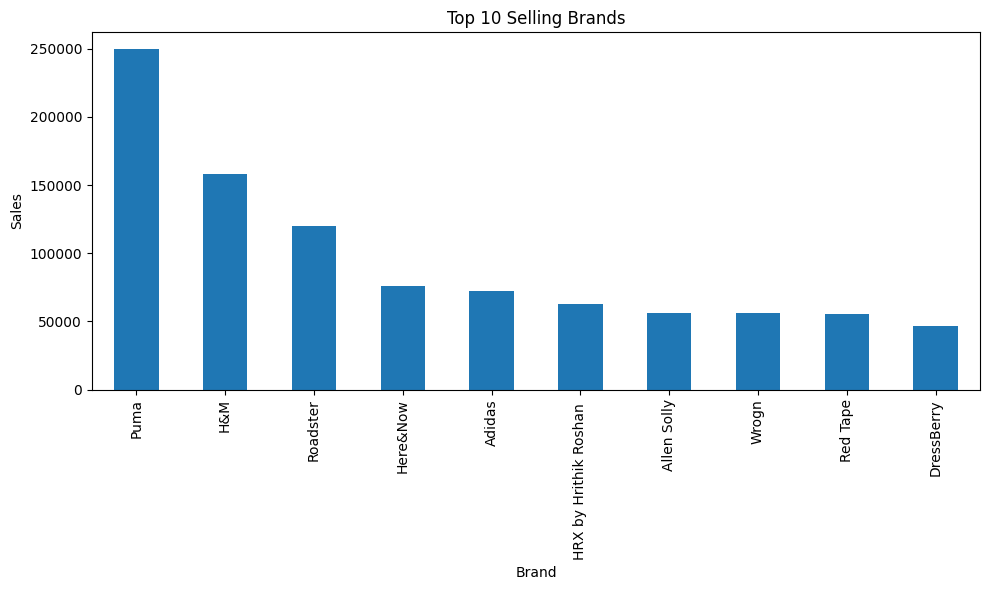

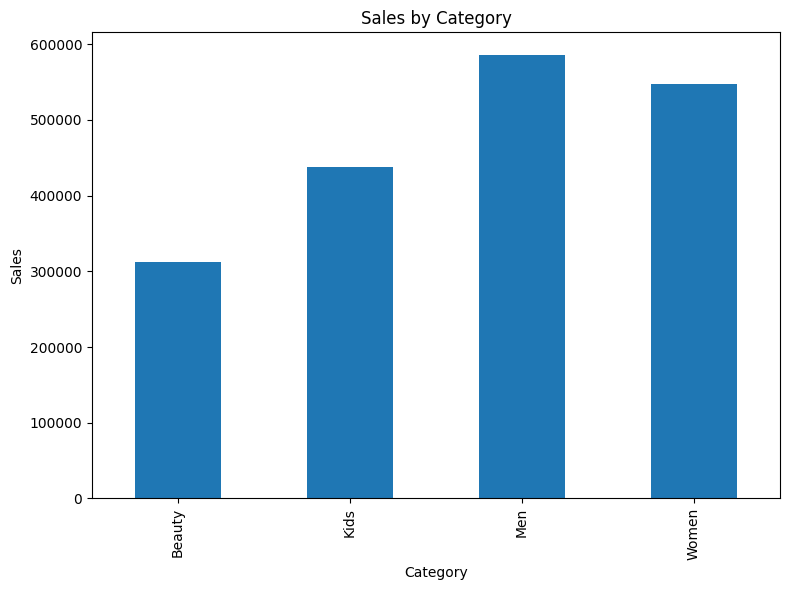

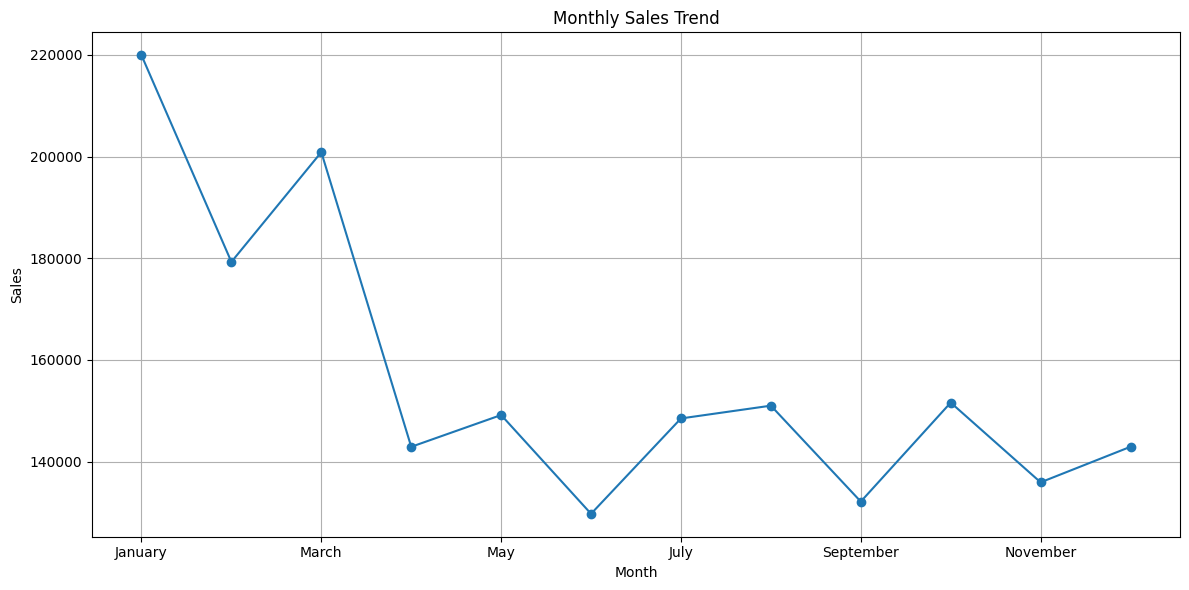

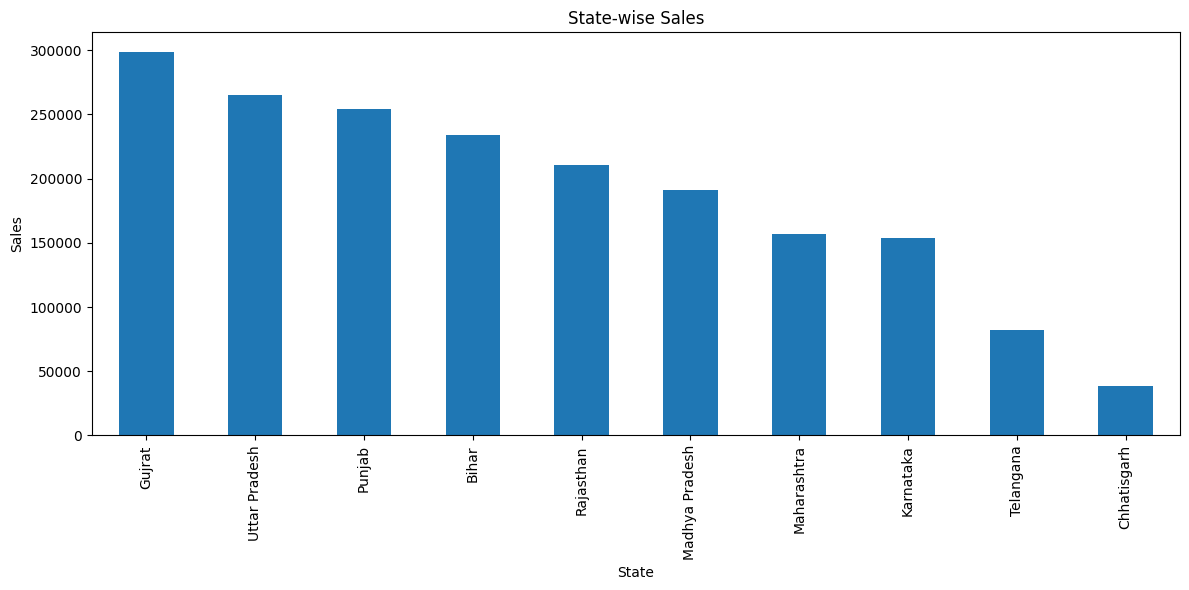

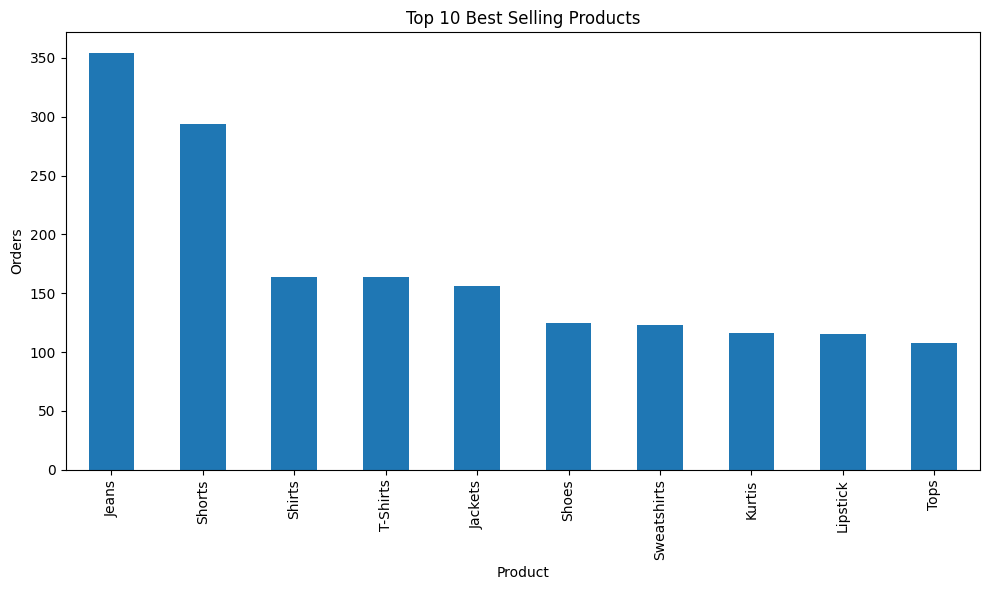

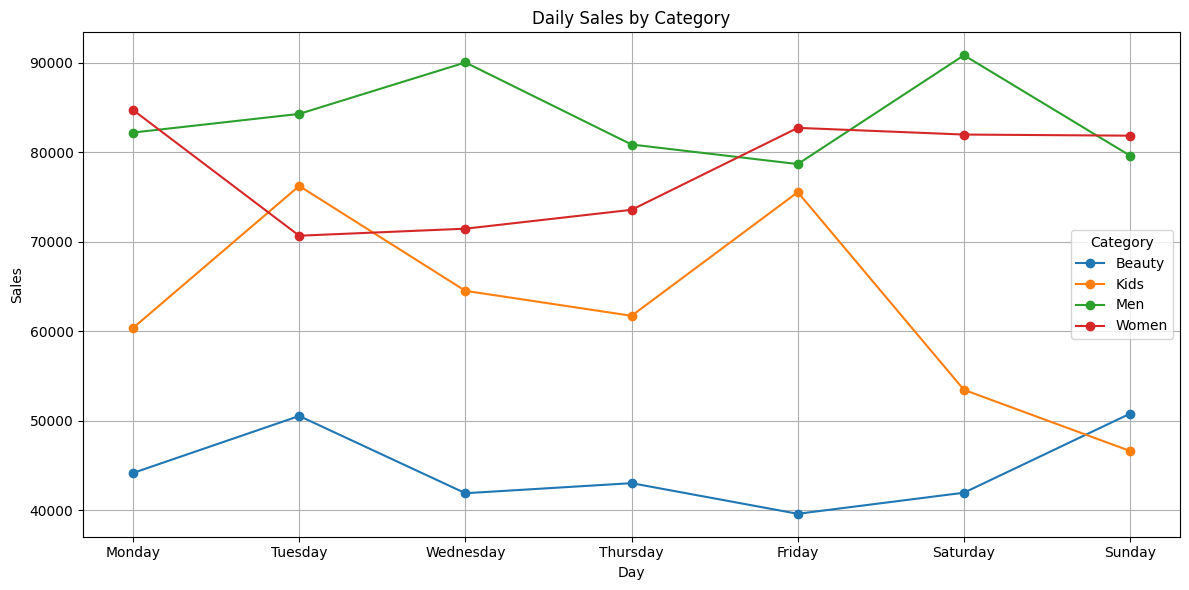

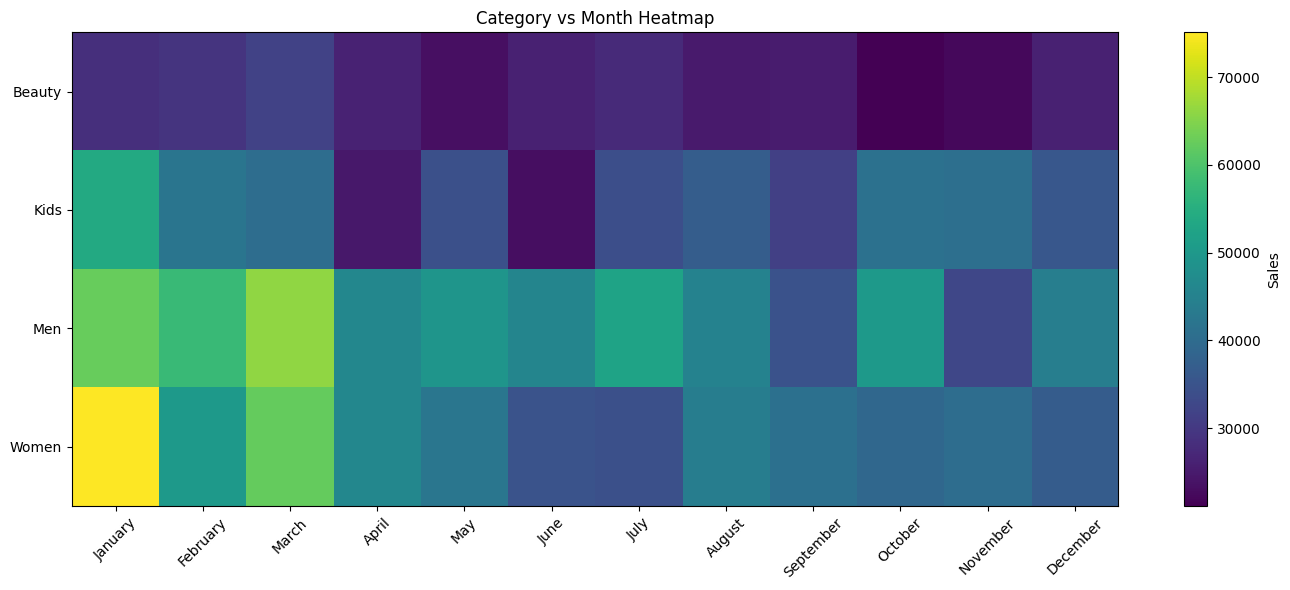

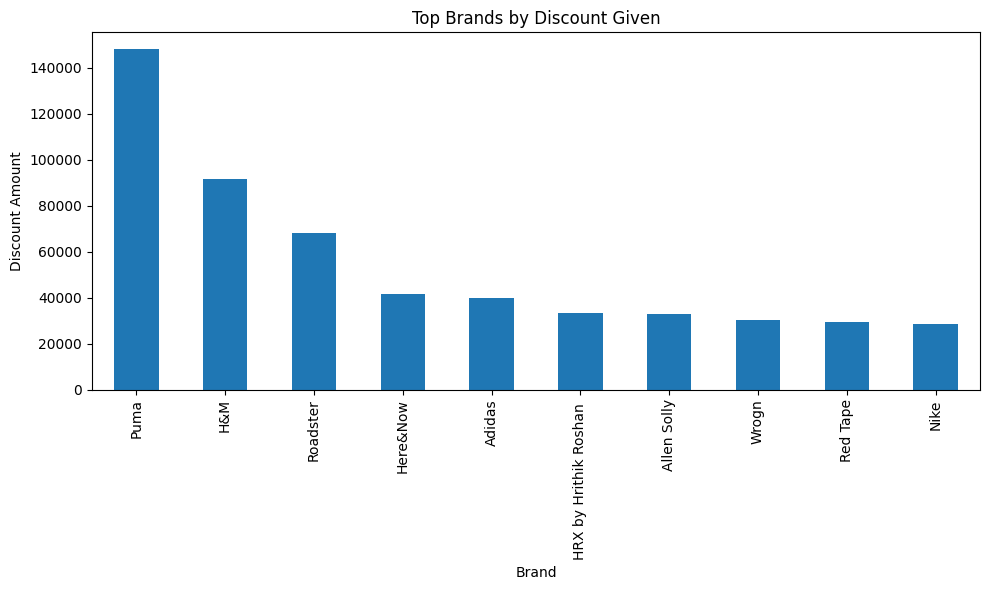


Analysis Completed Successfully ✅
Output file saved as: Myntra_Final_Analysis_Output.xlsx


In [ ]:



! pip install pandas numpy matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# STEP 1: Load Dataset


file_path = "Myntra dataset.xlsx"

products = pd.read_excel(file_path, sheet_name='dim_products ')
customers = pd.read_excel(file_path, sheet_name='dim_customers')
orders = pd.read_excel(file_path, sheet_name='fact_orders')

print("Products Shape:", products.shape)
print("Customers Shape:", customers.shape)
print("Orders Shape:", orders.shape)


# STEP 2: Clean Column Names


products.columns = products.columns.str.strip()
customers.columns = customers.columns.str.strip()
orders.columns = orders.columns.str.strip()


# STEP 3: Merge Tables


df = orders.merge(products, on='Product ID')
df = df.merge(customers, on='Customer ID')


# STEP 4: Create Sales Columns


df['Discount Amount'] = df['Original Price'] * df['Discount%']
df['Final Price'] = df['Original Price'] - df['Discount Amount']

# Date Conversion
df['Date'] = pd.to_datetime(df['Date'])

# Year, Month, Day Extraction
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()


# STEP 5: KPI Metrics


total_orders = df['Order ID'].nunique()
total_products = df['Product ID'].nunique()
total_sales = df['Final Price'].sum()
avg_sales = df['Final Price'].mean()
total_revenue = df['Original Price'].sum()

print("\n===== KPI RESULTS =====")
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Sales:", round(total_sales,2))
print("Average Sales:", round(avg_sales,2))
print("Total Revenue:", round(total_revenue,2))


# STEP 6: Top Selling Brands


brand_sales = df.groupby('Brand Name')['Final Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
brand_sales.plot(kind='bar')
plt.title('Top 10 Selling Brands')
plt.xlabel('Brand')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


# STEP 7: Category Sales


category_sales = df.groupby('Category')['Final Price'].sum()

plt.figure(figsize=(8,6))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


# STEP 8: Monthly Sales Trend


monthly_sales = df.groupby('Month')['Final Price'].sum()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


# STEP 9: State-wise Sales


state_sales = df.groupby('State')['Final Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_sales.plot(kind='bar')
plt.title('State-wise Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


# STEP 10: Best Selling Products


best_products = df.groupby('Product Name')['Order ID'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
best_products.plot(kind='bar')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()


# STEP 11: Daily Category Sales


daily_category = df.groupby(['Day','Category'])['Final Price'].sum().unstack()

daily_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_category = daily_category.reindex(daily_order)

daily_category.plot(figsize=(12,6), marker='o')
plt.title('Daily Sales by Category')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


# STEP 12: Heatmap for Category vs Month


heatmap_data = df.pivot_table(
    values='Final Price',
    index='Category',
    columns='Month',
    aggfunc='sum'
)

heatmap_data = heatmap_data.reindex(columns=month_order)

plt.figure(figsize=(14,6))
plt.imshow(heatmap_data, aspect='auto')

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.colorbar(label='Sales')
plt.title('Category vs Month Heatmap')
plt.tight_layout()
plt.show()


# STEP 13: Discount Analysis


discount_analysis = df.groupby('Brand Name')['Discount Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
discount_analysis.plot(kind='bar')
plt.title('Top Brands by Discount Given')
plt.xlabel('Brand')
plt.ylabel('Discount Amount')
plt.tight_layout()
plt.show()


# STEP 14: Export Final File


df.to_excel("Myntra_Final_Analysis_Output.xlsx", index=False)

print("\nAnalysis Completed Successfully ✅")
print("Output file saved as: Myntra_Final_Analysis_Output.xlsx")

In [5]:
%pip install sqlalchemy pymysql

# Install once in terminal:
# pip install sqlalchemy pymysql openpyxl pandas

import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# =========================
# Load Excel File
# =========================

file_path = r"D:\myntra sales\Myntra_Final_Analysis_Output.xlsx"
df = pd.read_excel(file_path)

# =========================
# Remove unwanted columns
# =========================

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# =========================
# Rename columns for SQL safety
# =========================

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('%', 'Percentage')

# =========================
# MySQL Connection
# =========================

username = 'root'
password = quote_plus('Hitesh@9')   # fixes @ symbol
host = 'localhost'
port = '3306'
database = 'myntra_project'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

# =========================
# Send Data to SQL
# =========================

df.to_sql(
    name='myntra_sales',
    con=engine,
    if_exists='replace',
    index=False
)

print("Data imported successfully into MySQL ✅")

  Using cached pymysql-1.1.2-py3-none-any.whl.metadata (4.3 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB 325.1 kB/s eta 0:00:07
   -- ------------------------------------- 0.1/2.1 MB 1.1 MB/s eta 0:00:02
   ------------- -------------------------- 0.7/2.1 MB 4.0 MB/s eta 0:00:01
   ---------------- ----------------------- 0.9/2.1 MB 4.0 MB/s eta 0:00:01
   ------------------- -------------------- 1.1/2.1 MB 3.9 MB/s eta 0:00:01
   ----------------------- ---------------- 1.2/2.1 MB 3.9 MB/s eta 0:00:01
   -------------------------- ------------- 1.4/2.1 MB 4.0 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data imported successfully into MySQL ✅
